# 1.6 - Statistiques descriptives

**Navigation** : [<< 1.5 Exploration](1.5-Exploration_Nettoyage_Donnees_Reelles.ipynb) | [Index](../README.md)

**Durée indicative** : ~60 min.

**Jeu de données** : `data/penguins.csv` — la table propre des manchots de Palmer (344 × 8, provenance : `data/PROVENANCE.md`), celle que le nettoyage de 1.5 a reproduite décision par décision.


## Objectifs d'apprentissage

1. Résumer une série par la **tendance centrale** : moyenne, médiane, mode — et savoir laquelle lire.
2. Mesurer la **dispersion** : étendue, écart-type, coefficient de variation, quartiles.
3. Reconnaître une **distribution** : skewness (asymétrie), et le test que le chiffre suggère mais ne remplace pas.
4. Calculer une **corrélation** et la tenir à distance de la causalité — le cas Simpson, mesuré ici.
5. Savoir **quand s'arrêter** : les statistiques descriptives répondent « que voit-on », pas « est-ce réel » — la suite (inférence, modèles) est dans [`Probas/`](../../Probas/README.md).

## Pourquoi après la visualisation

La figure donne l'intuition, le chiffre la rend mesurable : « la Gentoo est plus lourde » devient « médiane 4700 g vs 3700 g ». Les deux gestes se valident l'un l'autre — un nombre sans figure cache les structures (1.4), une figure sans nombre n'est pas falsifiable.


In [1]:
import pandas as pd
import numpy as np

manchots = pd.read_csv("../data/penguins.csv")
print("dimensions :", manchots.shape)
manchots.head()


dimensions : (344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 1. Tendance centrale : trois réponses à « la valeur typique »

La **moyenne** (somme / effectif) est le centre de gravité — sensible aux extrêmes. La **médiane** (valeur centrale une fois trié) résiste aux extrêmes : la moitié des valeurs est en dessous, la moitié au-dessus. Le **mode** est la valeur la plus fréquente — utile surtout pour les catégories (l'espèce dominante), quasi inutile sur des mesures continues.


In [2]:
masse = manchots["body_mass_g"].dropna()
print("moyenne   :", round(masse.mean(), 1), "g")
print("mediane   :", masse.median(), "g")
print("mode      :", manchots["species"].mode().iloc[0], "(espece la plus frequente)")
print("effectif le plus frequent d'une espece :",
      manchots["species"].value_counts().max())


moyenne   : 4201.8 g
mediane   : 4050.0 g
mode      : Adelie (espece la plus frequente)
effectif le plus frequent d'une espece : 152


**Lecture.** Moyenne 4202 g et médiane 4050 g : la moyenne **tire vers le haut** par rapport à la médiane — signe d'une distribution étalée vers les fortes masses (les Gentoo). Quand les deux coïncident, la distribution est à peu près symétrique ; quand elles s'écartent, elle ne l'est pas. C'est déjà un diagnostic — avant tout calcul d'asymétrie formel.


## 2. Dispersion : à quel point les valeurs s'écartent

L'**étendue** (max − min) est la dispersion brute. L'**écart-type** (σ) mesure l'écart moyen à la moyenne — dans les mêmes unités que la donnée. Le **coefficient de variation** (σ / moyenne) les rapporte l'un à l'autre, comparable entre variables d'échelles différentes. Les **quartiles** découpent la série en quatre (25 %, 50 %, 75 %) et structurent la boîte à moustaches de 1.4.


In [3]:
print("etendue     :", masse.max() - masse.min(), "g   (de", masse.min(), "a", masse.max(), ")")
print("ecart-type  :", round(masse.std(), 1), "g")
print("coef. var.  :", round(100 * masse.std() / masse.mean(), 1), "%")
print("quartiles   :", masse.quantile([0.25, 0.5, 0.75]).tolist())
print("IQR         :", round(masse.quantile(0.75) - masse.quantile(0.25), 1), "g")


etendue     : 3600.0 g   (de 2700.0 a 6300.0 )
ecart-type  : 802.0 g
coef. var.  : 19.1 %
quartiles   : [3550.0, 4050.0, 4750.0]
IQR         : 1200.0 g


**Lecture.** Un écart-type de 802 g sur une moyenne de 4202 g donne un coefficient de variation de 19 % — une dispersion réelle. L'IQR de 1200 g encadre la moitié centrale des masses : tout manchot entre 3550 et 4750 g est « typique ». La boîte à moustaches de 1.4 n'était autre que ces chiffres dessinés.


## 3. Distribution : l'asymétrie se mesure

La **skewness** (asymétrie) chiffre ce que l'œil voit : 0 = symétrique, > 0 = queue à droite (des grandes valeurs étirent la distribution), < 0 = queue à gauche. La mesure suggère le *type* de distribution ; un **test formel** (normalité, etc.) appartient à l'inférence — mentionné ici comme horizon, non utilisé.


In [4]:
# Asymetrie de la masse : melangee puis par espece
print("skewness masse (ensemble) :", round(masse.skew(), 2))
for espece in ["Adelie", "Chinstrap", "Gentoo"]:
    sous = manchots.loc[manchots["species"] == espece, "body_mass_g"].dropna()
    print(f"  {espece:10s} : {round(sous.skew(), 2)}   (n={len(sous)})")


skewness masse (ensemble) : 0.47
  Adelie     : 0.29   (n=151)
  Chinstrap  : 0.25   (n=68)
  Gentoo     : 0.07   (n=123)


**Lecture.** Sur l'ensemble, l'asymétrie est modérée à droite (+0,47) : les Gentoo lourdes étirent la distribution. **Au sein de chaque espèce**, elle s'effondre (entre +0,07 et +0,29) : chaque sous-population est à peu près symétrique. C'est la leçon du chiffre : une asymétrie apparente peut être l'effet du **mélange** de groupes bien réguliers — d'où l'intérêt de toujours recalculer par sous-groupe.


## 4. Corrélation ≠ causalité : le cas Simpson, mesuré

La corrélation de Pearson mesure la force d'une relation **linéaire** entre deux variables (+1 = croissante parfaite, −1 = décroissante parfaite, 0 = aucune relation linéaire). Elle ne dit ni la direction de la cause, ni s'il y en a une. Le **paradoxe de Simpson** le montre de façon spectaculaire : une tendance dans le mélange peut s'inverser dans chaque sous-groupe. Nous l'avons croisé en 1.4 sur la heatmap — mesurons-le.


In [5]:
# Longueur vs profondeur du bec : ensemble puis par espece
complet = manchots.dropna(subset=["bill_length_mm", "bill_depth_mm"])
print("correlation (ensemble) :",
      round(complet["bill_length_mm"].corr(complet["bill_depth_mm"]), 3))
for espece in ["Adelie", "Chinstrap", "Gentoo"]:
    sous = complet[complet["species"] == espece]
    print(f"  {espece:10s} :",
          round(sous["bill_length_mm"].corr(sous["bill_depth_mm"]), 3))


correlation (ensemble) : -0.235
  Adelie     : 0.391
  Chinstrap  : 0.654
  Gentoo     : 0.643


**Lecture.** Sur l'ensemble, la corrélation est **−0,24** : en moyenne, un bec plus long va avec un bec moins profond. Au sein de chaque espèce, elle est **positive** (+0,39 à +0,65) : chez une même espèce, un bec plus long va avec un bec plus profond. Le signe s'inverse à cause de la **composition** : les espèces à bec long (Gentoo, Chinstrap) ont justement des becs peu profonds, et la juxtaposition des trois nuages dessine une pente négative qui n'existe nulle part ailleurs que dans le mélange.

C'est le paradoxe de Simpson, mesuré. Deux conséquences durables : (1) une corrélation se calcule **toujours** sur la population homogène pertinente, jamais par défaut sur un mélange ; (2) aucun coefficient ne dit *pourquoi* — la causalité demande un modèle causal, une expérience, ou une hypothèse explicite. Les trois sont l'affaire des notebooks [`Probas/`](../../Probas/README.md) et de `DecisionTheory/Causal-Bridges`.


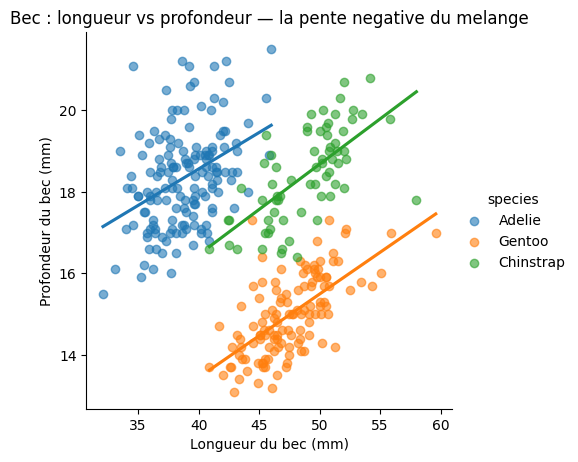

In [6]:
# Le meme phenomene, dessine : la pente du melange ne vit dans aucune espece
import matplotlib.pyplot as plt
import seaborn as sns

sns.lmplot(data=complet, x="bill_length_mm", y="bill_depth_mm",
           hue="species", height=4.5, scatter_kws={"alpha": 0.6}, ci=None)
plt.title("Bec : longueur vs profondeur — la pente negative du melange")
plt.xlabel("Longueur du bec (mm)"); plt.ylabel("Profondeur du bec (mm)")
plt.show()


## 5. Le résumé en une ligne

`describe()` produit le résumé canonique — tendance, dispersion, quartiles — pour toutes les colonnes numériques. C'est le geste de première rencontre chiffrée, à compléter des mesures ciblées des sections 1-3.


In [7]:
manchots.drop(columns=["year"]).describe().round(1)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.0,342.0,342.0,342.0
mean,43.9,17.2,200.9,4201.8
std,5.5,2.0,14.1,802.0
min,32.1,13.1,172.0,2700.0
25%,39.2,15.6,190.0,3550.0
50%,44.4,17.3,197.0,4050.0
75%,48.5,18.7,213.0,4750.0
max,59.6,21.5,231.0,6300.0


**Lecture.** Le tableau confirme tout ce qui précède : masses de 2700 à 6300 g (moyenne 4202, σ 802), becs de 32 à 60 mm de long et 13 à 21,5 mm de profondeur, ailes de 172 à 231 mm. Ce résumé est le point de départ de toute analyse — il *décrit*, il ne *conclut* pas.


## Exercices

Quatre exercices. Les cellules s'exécutent telles quelles ; remplacez les `None`/`pass`.


### Exercice 1 : tendance centrale par groupe

Pour chaque espèce, calculez moyenne et médiane de `flipper_length_mm`. Chez laquelle l'écart moyenne−médiane est-il le plus grand — et que suggère cet écart sur la symétrie ?


In [8]:
# Exercice 1 : moyenne vs mediane par espece
for espece in ["Adelie", "Chinstrap", "Gentoo"]:
    sous = None  # TODO: manchots.loc[manchots["species"] == espece, "flipper_length_mm"].dropna()
    pass  # TODO: calculer et afficher moyenne, mediane, ecart
print("Exercice a completer")


Exercice a completer


### Exercice 2 : dispersion relative

Le coefficient de variation permet de comparer des dispersions entre variables d'échelles différentes. Calculez-le pour `bill_length_mm` et pour `flipper_length_mm` (masse retirée). Laquelle des deux mesures est relativement **plus** dispersée ?


In [9]:
# Exercice 2 : coefficients de variation
# Etape 1: cv = 100 * std / mean sur chaque variable (avec dropna)
cv_bec = None  # TODO
cv_aile = None  # TODO
print("Exercice a completer : comparez cv_bec et cv_aile")


Exercice a completer : comparez cv_bec et cv_aile


### Exercice 3 : l'asymétrie par île

Calculez la skewness de `body_mass_g` par **île** cette fois. L'asymétrie est-elle plus forte sur une île en particulier — et que suggère ce résultat sur la composition de l'échantillon par île ?


In [10]:
# Exercice 3 : skewness par ile
for ile in ["Biscoe", "Dream", "Torgersen"]:
    sous = None  # TODO: manchots.loc[manchots["island"] == ile, "body_mass_g"].dropna()
    pass  # TODO: print(ile, round(sous.skew(), 2), len(sous))
print("Exercice a completer")


Exercice a completer


### Exercice 4 : Simpson, la variante

Reproduisez la section 4 sur **ailes vs masse** : corrélation de `flipper_length_mm` avec `body_mass_g` sur l'ensemble, puis par espèce. Le paradoxe apparaît-il aussi — ou la composition renforce-t-elle au contraire le signe ?


In [11]:
# Exercice 4 : correlation ailes-masse, ensemble puis par espece
complet2 = manchots.dropna(subset=["flipper_length_mm", "body_mass_g"])
# Etape 1: correlation sur l'ensemble
globale = None  # TODO
# Etape 2: meme calcul par espece
pass  # TODO
print("Exercice a completer")


Exercice a completer


## Conclusion

Ce notebook a mesuré ce que 1.4 faisait voir : tendance centrale (la moyenne tire vers le haut quand la distribution s'étale), dispersion (σ = 802 g, CV = 19 %), asymétrie (modérée en mélange, quasi nulle par espèce), corrélation (Simpson mesuré : −0,24 dans le mélange, +0,39 à +0,65 par espèce). Le geste durable : **toute statistique se recalcule sur la population homogène** — et la description n'est pas l'inférence. Pour la suite (tests, échantillonnage, modèles probabilistes) : la série [`Probas/`](../../Probas/README.md).

**Fin de la voie des prérequis** : 1.1 (Python) → 1.2 (NumPy) → 1.3 (Pandas) → 1.4 (Visualisation) → 1.5 (Exploration et nettoyage) → 1.6 (ce notebook) débouche sur [Lab 1](../Track1-LangChain/Day1-Foundations/Labs/Lab1-PythonForDataScience.ipynb) (mise en pratique) et [02-ML-Cours](../02-ML-Cours/README.md) (le socle scikit-learn).


## Références

1. W. McKinney, *Python for Data Analysis* (3ᵉ éd.) — chapitre 9 (statistiques descriptives avec pandas).
2. Pearson K., « Notes on the History of Correlation », *Biometrika* 13, 1920 — corrélation et ses limites.
3. Simpson E. H., « The Interpretation of Interaction in Contingency Tables », *JRSS-B* 13(2), 1951 — le paradoxe.
4. Station Palmer LTER / K. Gorman — données Penguin size clutches (2007-2009), voir `data/PROVENANCE.md`.
